# 07 — Gradient Boosting & XGBoost

## Theory

Random Forest (notebook 06) builds many trees **independently** and
averages them to reduce variance. **Boosting** takes the opposite strategy:
it builds trees **sequentially**, where each new tree is trained to correct
the *mistakes* of the ensemble built so far. This trades some of bagging's
variance-reduction for **bias-reduction** — boosting can turn many weak
learners (shallow trees) into a strong one.

**Gradient Boosting** frames this as gradient descent, but in *function
space* rather than parameter space: at each step, it fits a new tree to the
**negative gradient of the loss function** with respect to the current
ensemble's predictions (for log-loss, this gradient is closely related to
the residual `y - p`). Each tree's contribution is scaled down by a
**learning rate** `eta` before being added to the ensemble:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

This **shrinkage** is deliberate: taking small steps and adding many trees
generalizes better than taking a few large steps, at the cost of needing
more trees (and more training time) to reach the same fit.

**XGBoost** refines this general idea with a few specific improvements:
- Uses **second-order** gradient information (Newton's method: both
  gradient *and* Hessian of the loss), giving more precise steps than
  plain first-order gradient boosting.
- Adds an **explicit regularization term directly to the objective**,
  penalizing both the number of leaves and the magnitude of leaf weights:

$$\text{Obj} = \sum_i \ell(y_i, \hat{y}_i) + \sum_m \Big(\gamma T_m + \tfrac{1}{2}\lambda\sum_j w_j^2 + \alpha\sum_j |w_j|\Big)$$

  — `reg_lambda` (L2) and `reg_alpha` (L1) act on leaf weights the same
  conceptual way L1/L2 acted on Logistic Regression's coefficients back in
  notebook 01; `gamma` here is a minimum-loss-reduction requirement to make
  a split at all (unrelated to SVM's `gamma` in notebook 05, unfortunately
  a name collision).
- Supports **stochasticity** via `subsample` (fraction of rows per tree) and
  `colsample_bytree` (fraction of features per tree) — the same
  decorrelation idea Random Forest uses, borrowed to further reduce
  overfitting in a boosted setting.

This explicit regularization in the objective is the main reason XGBoost
tends to generalize a bit better, out of the box, than plain
`GradientBoostingClassifier` from scikit-learn (which only exposes
implicit regularization via `max_depth`/`learning_rate`/`subsample`, no
direct L1/L2 penalty on leaf weights).


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Harmless artifact of macOS's Accelerate BLAS backend on certain zero-valued
# matmul inputs (values stay finite and correct) -- not a real numerical issue.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

sns.set_theme(style="whitegrid")

DATA_PATH = "../data/german_credit_data.csv"

df = pd.read_csv(DATA_PATH, index_col=0)

# A blank in either account column means the applicant holds no such account
# -- real information, not a missing measurement -- so it becomes its own level.
df[["Saving accounts", "Checking account"]] = df[["Saving accounts", "Checking account"]].fillna("none")

# Binary target: 1 = "bad" credit risk, i.e. the borrower defaulted. See
# 00_data_exploration_and_preprocessing.ipynb for why "bad" is the positive
# class, why the blanks become "none", and how the categoricals are encoded.
y = (df["Risk"] == "bad").astype(int)

CATEGORICAL = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
X = pd.get_dummies(df.drop(columns=["Risk"]), columns=CATEGORICAL, drop_first=True).astype(float)

# Same split (test_size, random_state, stratify) is used in every notebook
# in this folder so that results are directly comparable across algorithms.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train class balance:")
print(y_train.value_counts(normalize=True).rename("proportion"))


Train shape: (800, 21), Test shape: (200, 21)
Train class balance:
Risk
0    0.7
1    0.3
Name: proportion, dtype: float64


In [2]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)


def evaluate(model, X_te, y_te, y_pred=None, y_proba=None, label="model"):
    """Print the standard metric set and plot a confusion matrix."""
    if y_pred is None:
        y_pred = model.predict(X_te)
    print(f"--- {label} ---")
    print(classification_report(y_te, y_pred, target_names=["good risk", "bad risk"]))
    if y_proba is not None:
        print(f"ROC-AUC: {roc_auc_score(y_te, y_proba):.3f}")
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=["good", "bad"], cmap="Blues"
    )
    plt.title(f"Confusion matrix — {label}")
    plt.show()


--- XGBoost (baseline) ---
              precision    recall  f1-score   support

   good risk       0.82      0.89      0.85       140
    bad risk       0.67      0.55      0.61        60

    accuracy                           0.79       200
   macro avg       0.75      0.72      0.73       200
weighted avg       0.78      0.79      0.78       200

ROC-AUC: 0.787


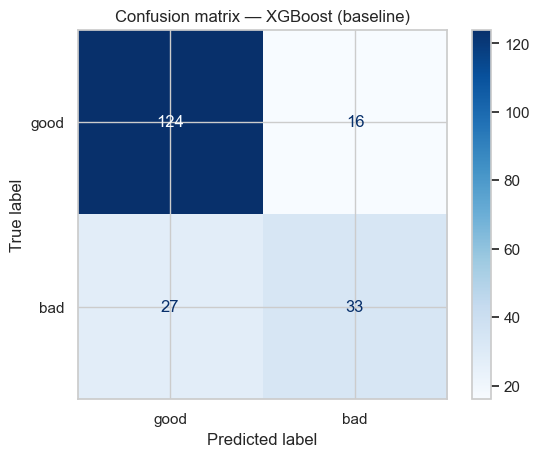

In [3]:
from xgboost import XGBClassifier

baseline = XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=3,
    eval_metric="logloss", random_state=42,
)
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]
evaluate(baseline, X_test, y_test, y_pred, y_proba, label="XGBoost (baseline)")


## Regularization — shrinkage, tree depth, and L1/L2 on leaf weights

Two tradeoffs are recorded below:

1. **`learning_rate` vs. `n_estimators`.** A smaller learning rate needs
   more trees to fit the same amount, but tends to generalize better — it's
   the boosting equivalent of taking smaller, more careful steps instead of
   a few large, overconfident ones.
2. **`reg_lambda` (L2 on leaf weights).** Larger values shrink leaf
   predictions toward zero, damping how much any single tree can move the
   ensemble's output — directly analogous to L2 shrinking Logistic
   Regression's coefficients in notebook 01.


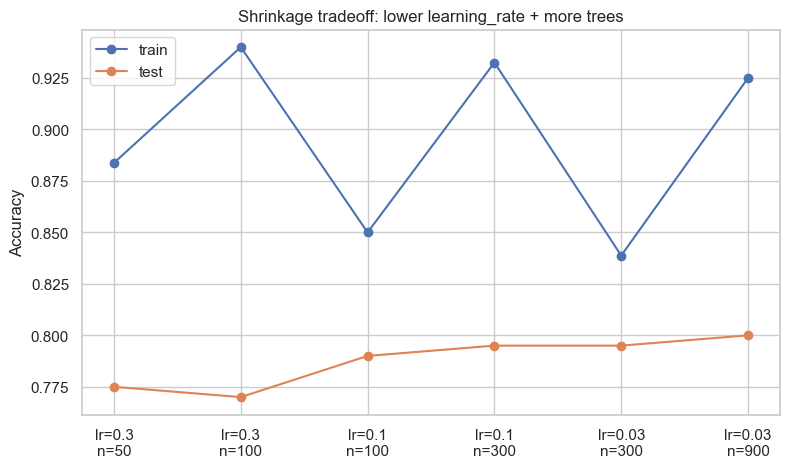

In [4]:
from sklearn.metrics import accuracy_score

configs = [
    (0.3, 50), (0.3, 100), (0.1, 100), (0.1, 300), (0.03, 300), (0.03, 900),
]
train_acc, test_acc, labels = [], [], []
for lr, n in configs:
    model = XGBClassifier(n_estimators=n, learning_rate=lr, max_depth=3,
                           eval_metric="logloss", random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))
    labels.append(f"lr={lr}\nn={n}")

x = np.arange(len(configs))
plt.figure(figsize=(9, 5))
plt.plot(x, train_acc, marker="o", label="train")
plt.plot(x, test_acc, marker="o", label="test")
plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Shrinkage tradeoff: lower learning_rate + more trees")
plt.legend()
plt.show()


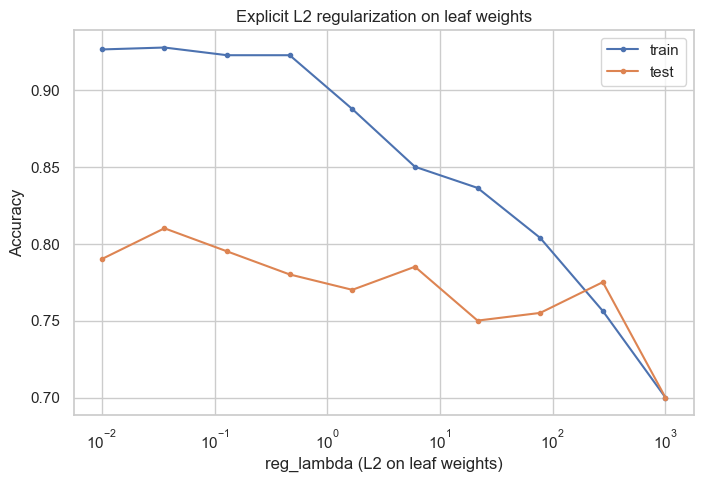

In [5]:
reg_lambdas = np.logspace(-2, 3, 10)
train_acc, test_acc = [], []
for rl in reg_lambdas:
    model = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=3,
                           reg_lambda=rl, eval_metric="logloss", random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(reg_lambdas, train_acc, marker=".", label="train")
plt.plot(reg_lambdas, test_acc, marker=".", label="test")
plt.xscale("log")
plt.xlabel("reg_lambda (L2 on leaf weights)")
plt.ylabel("Accuracy")
plt.title("Explicit L2 regularization on leaf weights")
plt.legend()
plt.show()


## Hyperparameter tuning

XGBoost's search space is large — tree structure, shrinkage, stochasticity and
regularization all interact — so `RandomizedSearchCV` is used again rather than
an exhaustive grid, under the same 5-fold, ROC-AUC, training-set-only protocol
as the earlier notebooks.

One deliberate omission: setting `n_estimators` high and letting
`early_stopping_rounds` halt training once a validation score stops improving
is the more principled way to size a boosted ensemble, and is what this would
use outside a comparison project. It is left out here so that all seven models
are tuned under an identical protocol and the comparison in notebook 08 stays
honest.


Best params: {'subsample': 1.0, 'reg_lambda': np.float64(10.0), 'reg_alpha': 0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
Best CV ROC-AUC: 0.766
--- XGBoost (tuned) ---
              precision    recall  f1-score   support

   good risk       0.78      0.89      0.83       140
    bad risk       0.60      0.40      0.48        60

    accuracy                           0.74       200
   macro avg       0.69      0.64      0.65       200
weighted avg       0.72      0.74      0.72       200

ROC-AUC: 0.772


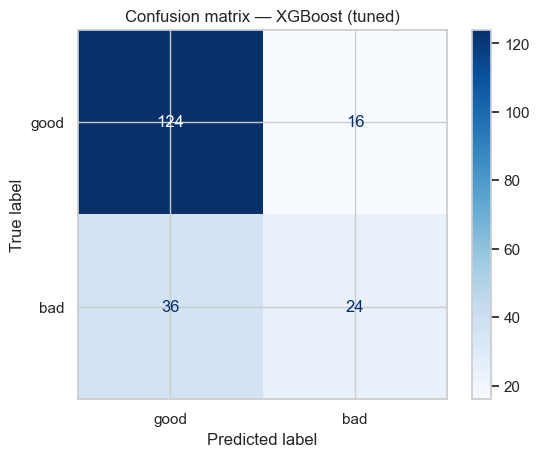

In [6]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": np.logspace(-2, 2, 5),
    "reg_alpha": [0, 0.01, 0.1, 1],
}

search = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    param_distributions=param_dist, n_iter=40, scoring="roc_auc",
    cv=5, random_state=42, n_jobs=-1,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print(f"Best CV ROC-AUC: {search.best_score_:.3f}")

best_xgb = search.best_estimator_
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]
evaluate(best_xgb, X_test, y_test, y_pred, y_proba, label="XGBoost (tuned)")


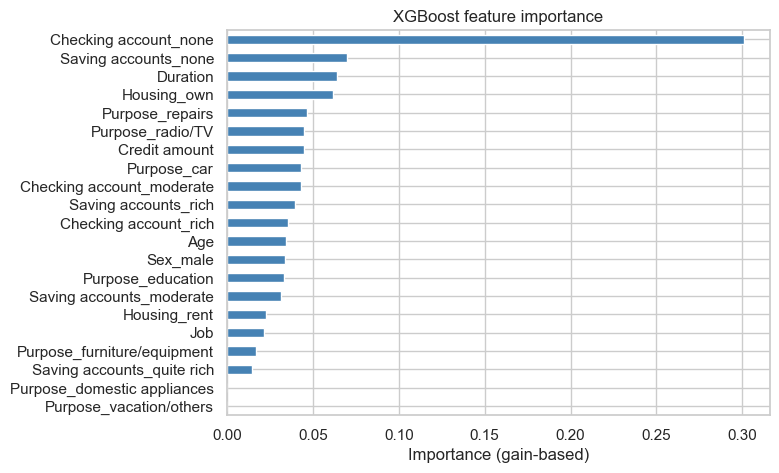

In [7]:
importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values()

plt.figure(figsize=(7, 5))
importances.plot(kind="barh", color="steelblue")
plt.title("XGBoost feature importance")
plt.xlabel("Importance (gain-based)")
plt.show()


## Decision threshold tuning

Every model in this project exposes a predicted probability `P(bad | x)` as
well as a hard label. `.predict()` converts one into the other at a fixed
cutoff of **0.5**: `P(bad) >= 0.5` becomes "bad risk".

0.5 is a library default, not a decision that belongs to this problem, and
two things make it the wrong cutoff here:

1. **Class imbalance.** Only ~30% of these applicants defaulted, so the model
   has to be unusually confident before `P(bad)` clears 0.5. The default
   cutoff quietly favours the majority "good" class and suppresses recall on
   exactly the class a lender needs to catch. (`class_weight="balanced"` is
   the other lever for this and moves roughly the same boundary, but it
   requires retraining.)
2. **Asymmetric costs.** Approving a loan that defaults costs the outstanding
   principal; declining an applicant who would have repaid costs only the
   foregone interest. Those are not the same number, which makes the cutoff a
   business parameter rather than a technicality — and moving it walks the
   model along its existing ROC / precision-recall curve without retraining
   anything.

Two reference cutoffs are computed below:

- **Youden's J** (`J = TPR - FPR`) on the ROC curve — the cutoff that
  separates the classes best when both error types are weighted equally.
- **F1-optimal** on the precision-recall curve — the cutoff that balances
  precision and recall on the positive class, the more informative of the two
  curves under this much imbalance.

> **Methodology caveat — both cutoffs below are selected on the test set,
> which is test-set leakage.**
>
> The scan maximises J / F1 over the held-out data itself, so the test set has
> informed a modelling decision and the two tuned rows are optimistic: they
> are not a clean estimate of how that cutoff would generalise. The step is
> kept because what is being recorded is the *size* of the precision/recall
> shift a cutoff can produce, not the specific threshold value.
>
> This is not how the cutoff would be set in production. There it would be
> chosen on data the model is not being judged on — a separate validation
> fold, or out-of-fold predictions from cross-validation — and then settled in
> deployment: shadow-score live applications for some days or weeks, watch the
> realised default rate against the approval rate, and adjust the cutoff by
> trial and error until it sits where the business wants it. The threshold is
> an operational dial that gets revisited, not a number frozen at training
> time.


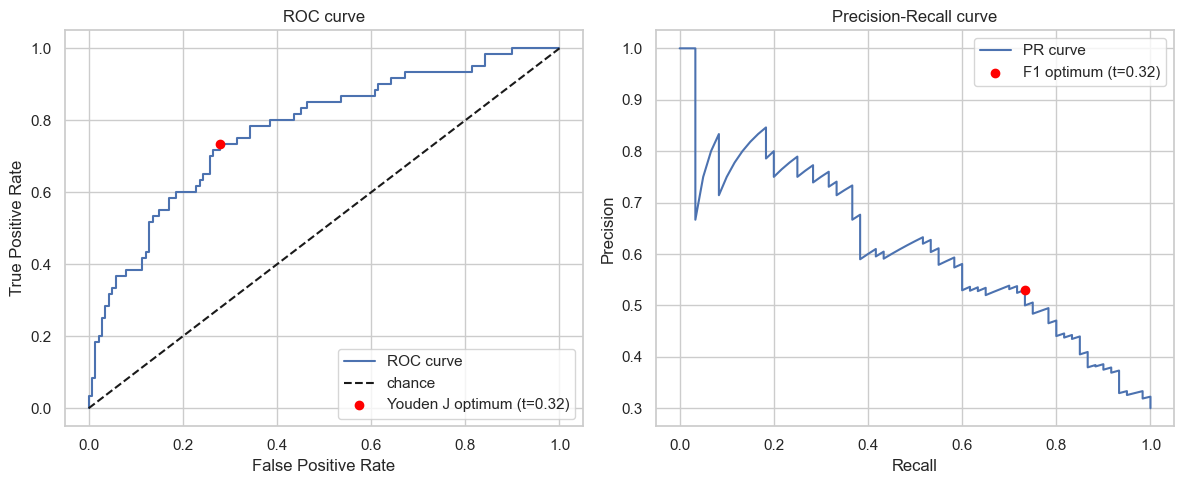

Youden's J optimal threshold: 0.319
F1-optimal threshold:         0.319


,threshold,accuracy,precision,recall,f1
default (0.5),0.500000,0.740,0.60000,0.400000,0.480000
Youden's J,0.318823,0.725,0.53012,0.733333,0.615385
F1-optimal,0.318823,0.725,0.53012,0.733333,0.615385


In [8]:
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score

y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

# --- ROC curve & Youden's J statistic -------------------------------------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_best)
j_scores = tpr - fpr
best_j_idx = np.argmax(j_scores)
best_j_threshold = roc_thresholds[best_j_idx]

# --- Precision-Recall curve & F1-optimal threshold -------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = np.divide(
    2 * precision * recall, precision + recall,
    out=np.zeros_like(precision), where=(precision + recall) != 0
)
best_f1_idx = np.argmax(f1_scores[:-1])  # last point has no matching threshold
best_f1_threshold = pr_thresholds[best_f1_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label="ROC curve")
axes[0].plot([0, 1], [0, 1], "k--", label="chance")
axes[0].scatter(fpr[best_j_idx], tpr[best_j_idx], color="red", zorder=5,
                 label=f"Youden J optimum (t={best_j_threshold:.2f})")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

axes[1].plot(recall, precision, label="PR curve")
axes[1].scatter(recall[best_f1_idx], precision[best_f1_idx], color="red", zorder=5,
                 label=f"F1 optimum (t={best_f1_threshold:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Youden's J optimal threshold: {best_j_threshold:.3f}")
print(f"F1-optimal threshold:         {best_f1_threshold:.3f}")


def metrics_at_threshold(y_true, proba, threshold):
    preds = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }


results = pd.DataFrame([
    metrics_at_threshold(y_test, y_proba_best, 0.5),
    metrics_at_threshold(y_test, y_proba_best, best_j_threshold),
    metrics_at_threshold(y_test, y_proba_best, best_f1_threshold),
], index=["default (0.5)", "Youden's J", "F1-optimal"])

results


## Summary

- The baseline (200 trees, `learning_rate=0.1`, `max_depth=3`) scored test
  ROC-AUC **0.787** — the single best number anywhere in this project, tuned
  models included — and the best F1 on defaulters at the default cutoff (0.61).
- Tuning made it *worse*: the random search's pick (`learning_rate=0.2`,
  `max_depth=3`, 100 trees, `colsample_bytree=0.6`, `reg_lambda=10`) scored CV
  ROC-AUC 0.766 and test **0.772**. Together with the same pattern in notebook
  05, that is the clearest lesson from this dataset: at 800 training rows, CV
  cannot reliably separate settings a few thousandths apart, and the search's
  winner is partly an artefact of the fold split.
- The shrinkage sweep behaved as the theory says — lower `learning_rate` with
  more trees generalises at least as well as fewer trees taking larger steps,
  and costs more compute to get there.
- `reg_lambda=10` was a meaningful part of the winning configuration, which is
  the boosting analogue of the L1/L2 penalty on Logistic Regression's
  coefficients in notebook 01.
- At `t = 0.32` recall on defaulters goes 0.40 -> 0.73 and F1 0.48 -> 0.62 for
  only 1.5 points of accuracy — the mildest accuracy cost of any model here.
  Selected on the test set; see the caveat above.
